# Session 4 — Demo 3 — Three traps

**What this demo covers.** Three ways smart people fool themselves with numbers — each one demonstrated live, on data where we *know* the truth in advance:

1. **Regression to the mean** — the worst group always improves, and nobody did anything
2. **Multiple comparisons** — test twenty things, one will shine
3. **Significant-but-tiny** — huge samples make everything "significant"

Each trap ends with the rule that defuses it, and all three rules land in the honest-verdict checklist at the bottom, the shape a strong HW1 Part 2 verdict has.

**Data.** The ALPHA week — [data dictionary](../../data/README.md).

**How to run.** Locally: top to bottom. Colab: uncomment the lines in the setup cell. Needs `scipy`.

## 0. Setup

Same imports as demo 1, `numpy` included, because we need its random generator again: every trap below is demonstrated on data we randomised ourselves, so that we know the honest answer before the test speaks.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

from scipy import stats

# where the data lives, relative to this notebook
DATA = Path("../../data/alpha")

# --- Google Colab? Uncomment these two lines to fetch the course repo: ---
# !git clone https://github.com/seemsGoodNow/hse-data-science-course.git course
# DATA = Path("course/data/alpha")

# missing a library? uncomment:
# %pip install pandas pyarrow matplotlib seaborn scipy

In [2]:
def make_ax_better(ax, minor=""):
    """Tidy one chart: drop the top/right frame, add a light grid.

    minor="x", "y" or "xy" also adds small ticks between the labelled ones.
    """
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    if "x" in minor:
        ax.xaxis.set_minor_locator(AutoMinorLocator())
    if "y" in minor:
        ax.yaxis.set_minor_locator(AutoMinorLocator())
    if minor:
        ax.tick_params(which="minor", length=2.5)
        ax.tick_params(which="major", length=5)
        ax.grid(which="minor", linewidth=0.15, color="tab:grey", alpha=0.25)
    ax.grid(linewidth=0.5, color="tab:grey", alpha=0.25)

The per-task table from demo 1, in the same single expression: same four collapsed steps, same `picks_per_hour`:

In [3]:
events = pd.read_parquet(DATA / "picking_events.parquet")
topology = pd.read_parquet(DATA / "topology.parquet")

picks = events[events["event_type"] == "PickCorrectItem"]
finished_ids = set(events.loc[events["event_type"] == "FinishTask", "task_id"])

tasks = (
    events
    .groupby("task_id")
    .agg(
        start=("event_time", "min"),
        end=("event_time", "max"),
    )
)
tasks["picks"] = picks.groupby("task_id").size()
tasks["picks"] = tasks["picks"].fillna(0).astype(int)
tasks["finished"] = tasks.index.isin(finished_ids)

tasks = tasks[tasks["finished"] & (tasks["picks"] > 0)]
tasks["duration_min"] = (tasks["end"] - tasks["start"]).dt.total_seconds() / 60
tasks["picks_per_hour"] = tasks["picks"] / (tasks["duration_min"] / 60)

picks_with_sector = picks.merge(
    topology[["cell_id", "sector_id"]],
    on="cell_id",
    how="left",
)
tasks["sector"] = picks_with_sector.groupby("task_id")["sector_id"].first().astype(int)

print(f"tasks kept for pace stats: {len(tasks):,}")

tasks kept for pace stats: 4,077


---

## 1. ❓ Trap #1 — "we talked to the slowest pickers and they got faster"

A manager ranks the week's pickers, takes the bottom three aside for a word, and looks again next week. They improved. Did the conversation work?

<details>
<summary>🔍 <b>What we'll do</b> — how would you find out? Think first</summary>

Build a world where we <i>know</i> nobody changed: twenty invented workers whose real pace is fixed for life, measured on two days with a different day's luck each time. Pick out the slowest five of day one and see what they do on day two. Then check the same thing on our real pickers, where nobody was taken aside at all.
</details>

Two tools for this one:

- **`rng.normal(centre, spread, how_many)`** draws that many numbers scattered around a centre. We use it twice: once for each worker's real pace, and again for the luck of each day.
- **`stats.linregress(x, y)`** fits the straight line that runs through a cloud of points. The field we want is `.slope`: **1.0 would mean today predicts tomorrow exactly**, and anything below it means the extremes come back towards the middle.

In [4]:
rng = np.random.default_rng(0)

# each worker's real pace, fixed all week. Nothing below ever changes it
true_pace = rng.normal(130, 25, 20)

# two days of work: the same skill, a different day's luck each time
toy_workers = pd.DataFrame({
    "true_pace": true_pace.round(0),
    "monday": (true_pace + rng.normal(0, 15, 20)).round(0),
    "tuesday": (true_pace + rng.normal(0, 15, 20)).round(0),
})

slowest_on_monday = toy_workers.sort_values("monday").head(5)
print("the five slowest on Monday, and what they did on Tuesday:")
print(slowest_on_monday.to_string(index=False))
print(
    f"\nas a group: {slowest_on_monday['monday'].mean():.0f} picks/h on Monday, "
    f"{slowest_on_monday['tuesday'].mean():.0f} on Tuesday"
)

the five slowest on Monday, and what they did on Tuesday:
 true_pace  monday  tuesday
      72.0    69.0     72.0
     114.0    99.0    120.0
      98.0   102.0    118.0
      99.0   102.0     80.0
     112.0   106.0    139.0

as a group: 96 picks/h on Monday, 106 on Tuesday


Read the `true_pace` column, because it is the thing you never get to see in real life. **One of those five is genuinely slow** (72 picks an hour, and he is still slow on Tuesday). The other four are ordinary workers who had a bad Monday, and on Tuesday they are ordinary again.

That is the whole mechanism. When you pick out the extremes of a measurement you are picking up **two things at once**: people who really are slower, and people who were unlucky that day. The first group stays. The second group evaporates, and it looks exactly like improvement.

One run could be a coincidence, so run the whole week five hundred times:

In [5]:
worst_moves = []
best_moves = []
rng = np.random.default_rng(7)

for _ in range(500):
    true_pace = rng.normal(130, 25, 20)
    one_week = pd.DataFrame({
        "monday": true_pace + rng.normal(0, 15, 20),
        "tuesday": true_pace + rng.normal(0, 15, 20),
    })
    slowest_five = one_week.sort_values("monday").head(5)
    fastest_five = one_week.sort_values("monday", ascending=False).head(5)
    worst_moves.append(
        slowest_five["tuesday"].mean() / slowest_five["monday"].mean() - 1
    )
    best_moves.append(
        fastest_five["tuesday"].mean() / fastest_five["monday"].mean() - 1
    )

worst_moves = pd.Series(worst_moves)
best_moves = pd.Series(best_moves)
print(
    f"500 weeks in which nobody's skill ever changed:\n"
    f"  the five slowest improved by {worst_moves.mean():+.1%} on average, "
    f"and improved at all in {(worst_moves > 0).mean():.0%} of weeks\n"
    f"  the five fastest  moved   {best_moves.mean():+.1%} on average, "
    f"and got worse in {(best_moves < 0).mean():.0%} of weeks"
)

500 weeks in which nobody's skill ever changed:
  the five slowest improved by +10.1% on average, and improved at all in 86% of weeks
  the five fastest  moved   -5.3% on average, and got worse in 84% of weeks


Ten percent improvement out of nothing, in five weeks out of six. **This effect has a name: regression to the mean**, and it is guaranteed by arithmetic before anybody opens their mouth.

Now our own pickers. Every worker who did at least two tasks on two days in a row, their pace on the first day against their pace on the second. Nobody at ALPHA was taken aside and spoken to during this week:

In [6]:
tasks["user_id"] = events.groupby("task_id")["user_id"].first()
tasks["day"] = tasks["start"].dt.date

worker_days = (
    tasks
    .groupby(["user_id", "day"])
    .agg(
        pace=("picks_per_hour", "mean"),
        tasks_done=("picks_per_hour", "size"),
    )
    .reset_index()
)
# one task is not a measurement of anyone
worker_days = worker_days[worker_days["tasks_done"] >= 2]

days = sorted(tasks["day"].unique())
day_pairs = []
for i in range(len(days) - 1):
    today, tomorrow = days[i], days[i + 1]
    pace_today = (
        worker_days[worker_days["day"] == today].set_index("user_id")["pace"]
    )
    pace_tomorrow = (
        worker_days[worker_days["day"] == tomorrow].set_index("user_id")["pace"]
    )
    day_pairs.append(
        pd.DataFrame({"today": pace_today, "tomorrow": pace_tomorrow}).dropna()
    )

consecutive_days = pd.concat(day_pairs)
print(f"worker-days with a day before and a day after: {len(consecutive_days)}")
consecutive_days.head(3).round(1)

worker-days with a day before and a day after: 118


,today,tomorrow
user_id,,
3145818,127.6,143.2
3792068,184.9,202.1
3922108,82.2,81.5


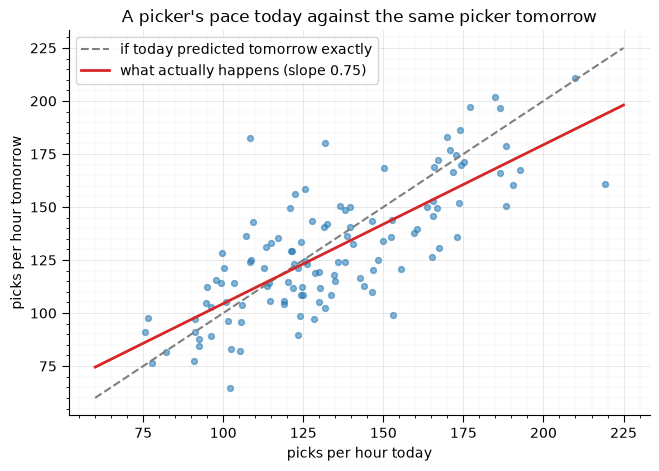

slowest quarter of a day: 97 picks/h, next day 103 (+6%)
fastest quarter of a day: 177 picks/h, next day 165 (-7%)


In [7]:
fitted_line = stats.linregress(
    consecutive_days["today"],
    consecutive_days["tomorrow"],
)

fig, ax = plt.subplots(figsize=(7.5, 5))

ax.scatter(
    consecutive_days["today"],
    consecutive_days["tomorrow"],
    s=18,
    alpha=0.55,
    color="tab:blue",
)
edges = np.array([60, 225])
ax.plot(
    edges,
    edges,
    ls="--",
    color="tab:grey",
    label="if today predicted tomorrow exactly",
)
ax.plot(
    edges,
    fitted_line.intercept + fitted_line.slope * edges,
    color="tab:red",
    lw=2,
    label=f"what actually happens (slope {fitted_line.slope:.2f})",
)
ax.set_title("A picker's pace today against the same picker tomorrow")
ax.set_xlabel("picks per hour today")
ax.set_ylabel("picks per hour tomorrow")
ax.legend()
make_ax_better(ax, minor="xy")

plt.show()

by_today = consecutive_days.sort_values("today")
quarter = len(by_today) // 4
slowest_quarter = by_today.head(quarter)
fastest_quarter = by_today.sort_values("today", ascending=False).head(quarter)
print(
    f"slowest quarter of a day: {slowest_quarter['today'].mean():.0f} picks/h, "
    f"next day {slowest_quarter['tomorrow'].mean():.0f} "
    f"({slowest_quarter['tomorrow'].mean() / slowest_quarter['today'].mean() - 1:+.0%})"
    "\n"
    f"fastest quarter of a day: {fastest_quarter['today'].mean():.0f} picks/h, "
    f"next day {fastest_quarter['tomorrow'].mean():.0f} "
    f"({fastest_quarter['tomorrow'].mean() / fastest_quarter['today'].mean() - 1:+.0%})"
)

✅ **What it means:** the red line is flatter than the grey one, and that gap is the trap. Our slowest quarter of a day came back up by 6%, our fastest quarter fell 7%, and **nobody intervened with anyone.** A manager who had spoken to the slow group would now be certain the conversation worked.

The slope also tells you how much of the ranking is worth anything. Both days have the same spread of workers, so a slope of 0.75 reads as: **about three quarters of the gap you see between people on a given day is real, and about a quarter is that day's luck.** It is the quarter that evaporates.

**The rule:** to claim an intervention worked, you need a comparison group picked out the same way that did *not* get the intervention. A ranking followed by a second look is not evidence, however large the improvement.

⛔ **What it does NOT mean:** that nobody is really slow. Three quarters of the spread is real, and worker 12 in the toy stayed at 72 picks an hour on both days. It means you cannot take credit for the size of the bounce. And it cuts both ways: **whoever tops your leaderboard this week will look worse next week**, with no one to blame for it.

---

## 2. ❓ Trap #2 — "we sliced the data and found something"

Twenty *meaningless* ways to split the tasks into two groups. We use random splits, which is morally identical to slicing by first letter of the item name, by odd or even id, by whatever else nobody hypothesised in advance:

Two spellings in the next cell. **`//`** is division that throws the fraction away (`9 // 2` is 4, not 4.5), because we need a whole number of tasks in each half. And **`ax.axhline(y)`** draws a horizontal reference line, the twin of session 3's `axvline`; the dots come from `ax.scatter(x, y)`, which you met in session 3's Crime #4.

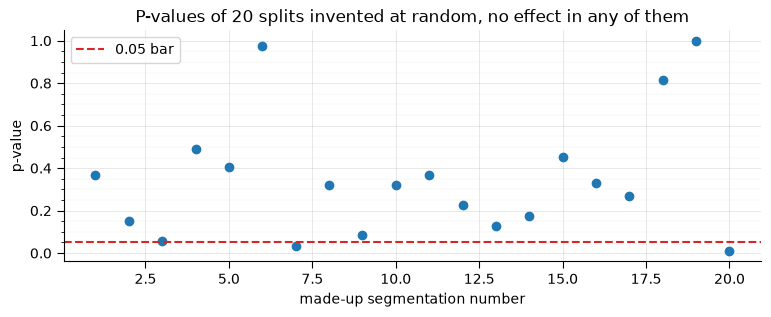

"significant" nonsense splits: 2 of 20


In [8]:
rng = np.random.default_rng(7)
all_task_pace = tasks["picks_per_hour"].dropna().to_numpy()

nonsense_p_values = []
for _ in range(20):
    shuffled = rng.permutation(all_task_pace)
    half = len(shuffled) // 2
    nonsense_p_values.append(
        stats.ttest_ind(
            shuffled[:half],
            shuffled[half:],
            equal_var=False,
        ).pvalue
    )

fig, ax = plt.subplots(figsize=(9, 3))

ax.scatter(range(1, 21), nonsense_p_values, color="tab:blue")
ax.axhline(0.05, color="tab:red", ls="--", label="0.05 bar")
ax.set_title("P-values of 20 splits invented at random, no effect in any of them")
ax.set_xlabel("made-up segmentation number")
ax.set_ylabel("p-value")
ax.legend()
make_ax_better(ax, minor="y")

plt.show()

significant_nonsense = 0
for p_value in nonsense_p_values:
    if p_value < 0.05:
        significant_nonsense += 1
print(f'"significant" nonsense splits: {significant_nonsense} of 20')

✅ **What it means:** test twenty things and roughly one shines by pure chance. That is not a bug, it is the literal definition of p < 0.05. The quick patch is **Bonferroni**: divide the bar by the number of tries (0.05 / 20 = 0.0025). The real fix: **decide what you test before looking.**

⛔ **What it does NOT mean:** that slicing data is forbidden. Exploration is how hypotheses are born, but you cannot use the same data to *confirm* what it suggested to you. Found a shiny slice? That is a hypothesis for next week's data, not a finding for this week's report.

Now the flip side of the same coin, on groups that are perfectly real: the wrong-scan rate of all 18 item categories, each against everything else.

One honest note before the numbers. A category lives on `item_id`, so joining to it costs us the 7,205 barcode-unresolved wrong scans, the very rows demo 2 caught the naive metric losing. Dropping them here is the right move, because a scan with no item has no category, but it moves the denominator: this table covers 172,016 attempts and averages **15.2%** wrong, while session 3's scoreboard counted all 179,221 attempts and said **18.6%**. Same warehouse, same week, two populations. Name which one you mean before you quote either number.

In [9]:
categories = pd.read_parquet(DATA / "categories.parquet")

category_attempts = (
    events[events["event_type"].isin(["PickCorrectItem", "PickWrongItem"])]
    .dropna(subset=["item_id"])
    .merge(categories, on="item_id", how="inner")
)
wrong_scans_total = (category_attempts["event_type"] == "PickWrongItem").sum()
print(
    f"pick attempts with a known item: {len(category_attempts):,}   "
    f"of them wrong: {wrong_scans_total:,}"
)

pick attempts with a known item: 172,016   of them wrong: 26,112


The loop below is session 3's Extras trick doing real work: **iterating a `groupby` hands you two things each turn**: the group's name (`"Home Living"`) and that group's rows as a small table of their own. Eighteen turns, eighteen chi-square tests.

It also builds a table the other way round from the toys of session 2. There we passed a dictionary of **columns**. Here the loop naturally finishes one **row** at a time, so we collect the rows in a list and hand `pd.DataFrame` the column names separately, in the order each row was built.

In [10]:
# we loop over 18 groups, not over 172,016 rows: looping over the ROWS of a
# dataframe is the classic pandas sin - slow, and it hides what is going on
category_tests = []
for category_name, category_group in category_attempts.groupby("category"):
    wrong = (category_group["event_type"] == "PickWrongItem").sum()
    total = len(category_group)
    rest_wrong = wrong_scans_total - wrong
    rest_total = len(category_attempts) - total
    category_chi_square = stats.chi2_contingency([
        [wrong, total - wrong],
        [rest_wrong, rest_total - rest_wrong],
    ])
    category_tests.append(
        (category_name, total, wrong / total, category_chi_square.pvalue)
    )

category_tests = pd.DataFrame(
    category_tests,
    columns=["category", "attempts", "wrong_rate", "p_value"],
).sort_values("p_value")

significant_categories = (category_tests["p_value"] < 0.05).sum()
bonferroni_survivors = (category_tests["p_value"] < 0.05 / 18).sum()
print(
    f'categories "significant" at 0.05:             '
    f"{significant_categories} of {len(category_tests)}\n"
    f"still significant after Bonferroni (0.05/18): "
    f"{bonferroni_survivors} of {len(category_tests)}"
)
category_tests.head(5).round(4)

categories "significant" at 0.05:             13 of 18
still significant after Bonferroni (0.05/18): 11 of 18


,category,attempts,wrong_rate,p_value
9,Home Living,15251,0.1782,0.0
5,Footwear,15860,0.1265,0.0
6,Garden & Seasonal,2432,0.2142,0.0
8,Health Store,8707,0.1222,0.0
2,Books & Media,7033,0.1236,0.0


**Read the `p_value` column again.** It says `0.0`, and one notebook ago we banned exactly that: *"write `p < 0.0001`, never `p = 0`"*. Nothing is broken. `.round(4)` keeps four decimals, and every one of these p-values sits far below the fourth one. The smallest is about `2e-21`. Rounding is a **display** choice, and this one just made the screen say something false. Before this table goes anywhere, print that column without the rounding, or write each cell as the number it actually is.

✅ **What it means:** almost everything is "significant", and most of it survives Bonferroni too, because with 172,016 attempts, even a microscopic difference in rates becomes impossible to blame on luck. **At big n, significance is cheap.** What still costs something is the *effect size*: Home Living at 17.8% wrong scans against this table's 15.2% average is worth a conversation; a category sitting at 15.4% is not, whatever its p-value says.

⛔ **What it does NOT mean:** that surviving Bonferroni makes a finding important, or that these 18 tests were a legitimate way to find a story. We tested every category *because they were there*, which is trap #2 in respectable clothing. A real finding survives the correction **and** has an effect size worth money, like the SmallParts ×1.5 from demo 2.

---

## 3. ❓ Trap #3 — "night shifts are significantly different, p = 0.00004"

Night versus day, **seconds per pick**: demo 2's column, rebuilt here in the same three lines. Mind the direction again, because on this metric smaller is faster. We run both tests, the default and the second opinion, and this time they will not agree.

In [11]:
events_by_task_time = events.sort_values(["task_id", "event_time"]).copy()
events_by_task_time["pick_seconds"] = (
    events_by_task_time
    .groupby("task_id")["event_time"]
    .diff()
    .dt.total_seconds()
)
timed_picks = events_by_task_time[
    (events_by_task_time["event_type"] == "PickCorrectItem")
    & events_by_task_time["pick_seconds"].notna()
    & (events_by_task_time["pick_seconds"] > 0)
].copy()

pick_hours = timed_picks["event_time"].dt.hour
timed_picks["is_night"] = (pick_hours >= 22) | (pick_hours < 6)

day_pick_seconds = timed_picks.loc[~timed_picks["is_night"], "pick_seconds"]
night_pick_seconds = timed_picks.loc[timed_picks["is_night"], "pick_seconds"]
night_ttest = stats.ttest_ind(
    day_pick_seconds,
    night_pick_seconds,
    equal_var=False,
)
night_mannwhitney = stats.mannwhitneyu(day_pick_seconds, night_pick_seconds)

print(
    f"n = {len(day_pick_seconds):,} day / {len(night_pick_seconds):,} night\n"
    f"median  day {day_pick_seconds.median():.2f} s   "
    f"night {night_pick_seconds.median():.2f} s   "
    f"({night_pick_seconds.median() / day_pick_seconds.median() - 1:+.1%})\n"
    f"mean    day {day_pick_seconds.mean():.2f} s   "
    f"night {night_pick_seconds.mean():.2f} s   "
    f"({night_pick_seconds.mean() / day_pick_seconds.mean() - 1:+.1%})\n"
    f"t-test p = {night_ttest.pvalue:.2f}   "
    f"Mann-Whitney p = {night_mannwhitney.pvalue:.1e}"
)

n = 84,105 day / 61,799 night
median  day 6.29 s   night 6.17 s   (-2.0%)
mean    day 10.52 s   night 10.66 s   (+1.3%)
t-test p = 0.38   Mann-Whitney p = 4.1e-05


✅ **What it means:** here is the headline somebody will bring you. *"Night picking is significantly different, p = 0.00004."* Now look at the whole output.

1. **The two tests disagree.** Our default, the t-test, says p = 0.38: nothing found. The rank test says 4.1e-05. Both are correct, because they are asking about different summaries, and the summaries point in **opposite directions**: on the mean the night is 1.3% *slower*, on the median it is 2.0% *faster*. When that happens, the honest reading is not "pick the test that agrees with me". It is *the two groups are so close that which number you choose decides the answer*.
2. **Significance is not size.** Both effects are about two percent. With 145,904 picks even a two-percent wobble clears the bar somewhere. A two-percent gap in pick time is a rounding error in any staffing decision.
3. **A surprising direction is a causal pause, not a conclusion.** Are night tasks and night workers the same population as day ones? Different people, different task mix, an emptier warehouse. No two-group test answers that.

⛔ **What it does NOT mean:** that night shifts are fine, or that they are faster, or that one of the two tests is broken. It means the two groups differ by about two percent on one metric, and that errors, safety and staffing cost were not in this comparison at all.

---

## The honest-verdict checklist

1. Hypothesis, **and what evidence would change your mind**, written *before* looking
2. Metric matches the **process** (SmallParts!)
3. Test matches the **data**: `ttest_ind` by default, a rank test beside it when the tail makes the mean unrepresentative, chi-square for shares, permutation for anything home-made
4. Report the **p-value AND the effect size**
5. Confounders checked: what else differs between the groups? (weights on the floor)
6. One look: decide the horizon, the slices and the test **before** you look. If two tests disagree, that is the finding, not an invitation to quote the friendlier one

*This is what a strong verdict looks like, and it is what "research logic" means in the HW1 rubric. HW1 does not require a test: a clear split, a chart and a defended verdict is already a complete Part 2. A test applied honestly is one of the three ways to earn the last two points. Your site, your numbers, the same machine.*

## Try it yourself

1. Re-run the toy with the luck turned down (`rng.normal(0, 5, 20)` instead of 15). Does the bounce get bigger or smaller, and why?
2. Take the top category from the table above: is its effect size worth a manager's attention? Write the one-sentence verdict.
3. Stretch: build a permutation test for the night-vs-day difference and see which of the two tests it sides with. Copy `simulate_luck_differences` from demo 1; it works here as it is.

In [12]:
# your turn

## Recap

- **Regression to the mean**: pick out the extremes of any measurement and part of what you picked was luck, so the group bounces back on its own. To claim credit you need a comparison group chosen the same way.
- **Twenty tests, one false shine**: Bonferroni, or better, pre-registration.
- **Big n makes p cheap**: a 2% effect is a shrug, not a headline; effect sizes decide.
- **When two legitimate tests disagree, that is the answer**, not a menu. Night versus day: p = 0.38 on means, 4e-05 on ranks, and the two summaries point opposite ways.
- A surprising direction demands a causal question (who works nights?), not another test.
- Rounding is a display choice, and it can print a lie: `p_value 0.0` is never a p-value.
- The checklist above is what a strong Part 2 verdict looks like; in HW1 a test strengthens the argument, it is not required. Deadline Wednesday 18:00, before class.

*Next week: machine learning on tables, on a dataset from your home turf. Which companies go bankrupt?*